In [652]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
import statsmodels.stats.outliers_influence as oi
import statsmodels.stats.api as sms


In [653]:
df = pd.read_csv('../data/regression_data_final.csv', sep=';') 
print(df.head())
print(df.describe())

                Регионы   X1    X2     X3     X4  X5_thous    X6    ln_Y
0  Белгородская область  4.9  65.4  17.40  57.19    -3.649  0.60 -0.4404
1      Брянская область  4.0  69.5  16.02  33.66    -1.588  0.57 -1.0505
2  Владимирская область  5.6  77.7  15.83  33.43    -3.588  0.59 -0.9044
3   Воронежская область  4.3  68.3  19.87  46.21     4.392  0.55 -0.7840
4    Ивановская область  5.4  81.8  16.16  15.34    -0.772  0.62 -1.2559
              X1         X2         X3          X4   X5_thous         X6       ln_Y
count  77.000000  77.000000  77.000000   77.000000  77.000000  77.000000  77.000000
mean    7.297403  69.012727  16.518312   65.705325   1.725532   0.590779  -0.847431
std     4.252862  11.877330   2.497553  113.698875  10.738884   0.058664   0.407703
min     3.600000  30.900000  10.730000    0.990000  -6.051000   0.440000  -1.954600
25%     5.000000  63.400000  15.240000    9.740000  -2.066000   0.550000  -1.092000
50%     6.000000  70.700000  16.560000   30.590000  -0.509

In [654]:
factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6']
target = df['ln_Y']
while len(factors) > 0:
    X = sm.add_constant(df[factors])
    model = sm.OLS(target, X).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break
print(model.summary())

Исключаем фактор 'X4' с p-value = 0.9372
Исключаем фактор 'X3' с p-value = 0.5144
Исключаем фактор 'X5_thous' с p-value = 0.2902
Исключаем фактор 'X6' с p-value = 0.3070
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     27.59
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.12e-09
Time:                        14:34:31   Log-Likelihood:                -18.220
No. Observations:                  77   AIC:                             42.44
Df Residuals:                      74   BIC:                             49.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err        

Получившаяся модель включает в себя два фактор, ее объясняющая способность 43%, что гораздо больше 25%. Значит решение о логарифмирование целевой переменной было правильным.

Проведем дисперсионный анализ, для оценки адекватности модели

In [655]:
ss_reg = model.ess             # Сумма квадратов
ss_res = model.ssr             # Сумма квадартов остатков
ss_total = ss_reg + ss_res     # Общая сумма

df_reg = model.df_model        # Степени свободы регрессии
df_res = model.df_resid        # Степени свободы остатков (n-k-1)

ms_reg = ss_reg / df_reg # Средние суммы квадратов регрессии
ms_res = ss_res / df_res #Средние суммы квадратов остатков

f_stat = model.fvalue
p_val = model.f_pvalue

print(f"{'Источник':<15} | {'SS':<10} | {'df':<5} | {'MS':<10}")
print("-" * 50)
print(f"{'Регрессия':<15} | {ss_reg:<10.4f} | {int(df_reg):<5} | {ms_reg:<10.4f}")
print(f"{'Остатки':<15} | {ss_res:<10.4f} | {int(df_res):<5} | {ms_res:<10.4f}")
print(f"{'Итого':<15} | {ss_total:<10.4f} | {int(df_reg + df_res):<5}")
print("-" * 50)
print(f"F-статистика: {f_stat:.4f}, p-value: {p_val:.10f}")

Источник        | SS         | df    | MS        
--------------------------------------------------
Регрессия       | 5.3961     | 2     | 2.6980    
Остатки         | 7.2368     | 74    | 0.0978    
Итого           | 12.6328    | 76   
--------------------------------------------------
F-статистика: 27.5888, p-value: 0.0000000011


Так как p < 0,05 следовательно модель значима. Проведем основные статистические тесты

{'Test Statistic': np.float64(11.356016239938732), 'Test Statistic p-value': np.float64(0.044760700651548344), 'F-Statistic': np.float64(2.4565149975745397), 'F-Test p-value': np.float64(0.041292709302071094)}


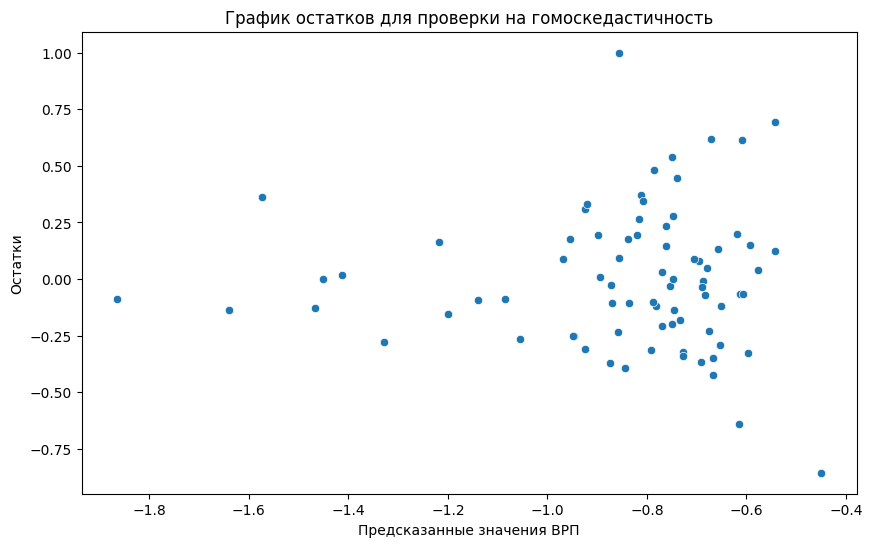

In [656]:
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(model.resid, model.model.exog)
print(dict(zip(labels, white_test)))

fitted_vals = model.fittedvalues # предсказания у
residuals = model.resid # остатки

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.xlabel('Предсказанные значения ВРП')
plt.ylabel('Остатки')
plt.title('График остатков для проверки на гомоскедастичность')
plt.show()

P-значение приблизилось к 0,05, значит логарифмирование переменной позволило снизить гетероскедастичность, но не убрать ее до конца

Теперь проведем тест Рамсея, который позволит понять есть ли ошибка спецификации.

In [657]:
reset_test = oi.reset_ramsey(model, degree=3)
print("ТЕСТ РАМСЕЯ:")
print(f"F-статистика: {float(reset_test.fvalue):.4f}")
print(f"p-value: {float(reset_test.pvalue):.4f}")

ТЕСТ РАМСЕЯ:
F-статистика: 0.9317
p-value: 0.3986


Так как полученное p-значение p = 0,399 что превышает уровень значимости 0,05, у нас нет оснований отвергнуть нулевую гипотезу. Значит необходимость включения дополнительных переменных или нелинейных преобразований не подтверждается.

Проверим остатки на нормальное распределение по тесту Харке — Бера.


In [658]:
name = ['Jarque-Bera', 'Chi^2 p-value']
test = sms.jarque_bera(model.resid)
print(dict(zip(name, test)))

{'Jarque-Bera': np.float64(5.509100000727065), 'Chi^2 p-value': np.float64(0.06363765014586782)}


Так как полученное p-значение p = 0,06, что превышает уровень значимости 0,05, значит мы не имеем основания отвергать гипотезу H0. Следовательно остатки распределены нормально.

Попробуем избавиться от гетероскедастичности, используя взвешенный МНК, как частный случай обобщенного МНК. Сначала определим, от какого регрессора больше зависит дисперсия, чтобы понять, какую переменную использовать как «вес». Для этого строим графики остатков против каждой объясняющей переменной X1 и X2.

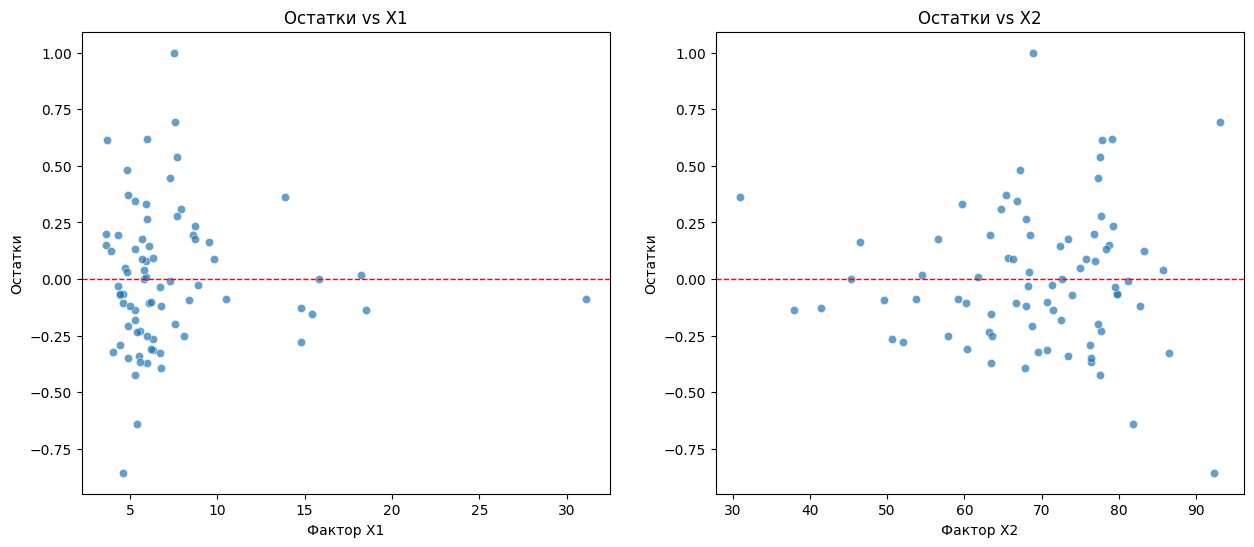

In [659]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# График остатков против X1
sns.scatterplot(x=df['X1'], y=model.resid, ax=ax[0], alpha=0.7)
ax[0].axhline(0, color='red', linestyle='--', linewidth=1)
ax[0].set_title('Остатки vs X1')
ax[0].set_xlabel('Фактор X1')
ax[0].set_ylabel('Остатки')

# График остатков против X2
sns.scatterplot(x=df['X2'], y=model.resid, ax=ax[1], alpha=0.7)
ax[1].axhline(0, color='red', linestyle='--', linewidth=1)
ax[1].set_title('Остатки vs X2')
ax[1].set_xlabel('Фактор X2')
ax[1].set_ylabel('Остатки')
plt.show()

Видим, что в X(2) образуется некая воронка, значит, именно эту переменную используем как «вес». 

In [660]:
weights_gretl = 1 / df['X2']
# Заново обучаем модель
X = sm.add_constant(df[['X1', 'X2']])
y = df['ln_Y']
wls_model = sm.WLS(y, X, weights=weights_gretl).fit()
print(wls_model.summary())

                            WLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.505
Model:                            WLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     37.72
Date:                Fri, 01 May 2026   Prob (F-statistic):           5.09e-12
Time:                        14:34:31   Log-Likelihood:                -15.978
No. Observations:                  77   AIC:                             37.96
Df Residuals:                      74   BIC:                             44.99
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4183      0.270     -5.258      0.0

In [661]:
print(f"F_критическое: {stats.f.ppf(0.95, 2, 74):.4f}")

F_критическое: 3.1203


Так как F наблюдеаемое сильно больше F критического, следовательно модель статистически значимая на 5% уровне значимости. Проведем тест Уайта на гетероскедастичность

In [662]:
weighted_resid = wls_model.resid * np.sqrt(wls_model.model.weights)

# Запускаем тест Уайта
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
white_test = sms.het_white(weighted_resid, wls_model.model.exog)
print(dict(zip(labels, white_test)))

{'Test Statistic': np.float64(7.453979083411925), 'Test Statistic p-value': np.float64(0.189006491962908), 'F-Statistic': np.float64(1.521963465190901), 'F-Test p-value': np.float64(0.19393213761119713)}


P значение > 0,05 следовательно остатки гомоскедастичны

Попробуем для общей модели прологарифмировать объясняющую переменную X4так как у не нарушено нормальное распределение, это было выявлено еще в предварительном анализе. Х5 достаточно проблематично логарифмировать так как есть значения сильно меньше -1.

In [663]:
# log X4
df['ln_X4'] = np.log(df['X4'])
factors = ['X1', 'X2', 'X3', 'ln_X4', 'X5_thous', 'X6']
target = df['ln_Y']

while len(factors) > 0:
    X = sm.add_constant(df[factors])
    model_log4 = sm.OLS(target, X).fit()
    p_values = model_log4.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break

print(model_log4.summary())

Исключаем фактор 'X3' с p-value = 0.5380
Исключаем фактор 'ln_X4' с p-value = 0.4821
Исключаем фактор 'X5_thous' с p-value = 0.2902
Исключаем фактор 'X6' с p-value = 0.3070
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     27.59
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.12e-09
Time:                        14:34:31   Log-Likelihood:                -18.220
No. Observations:                  77   AIC:                             42.44
Df Residuals:                      74   BIC:                             49.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err     

In [664]:
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
white_test = sms.het_white(model_log4.resid, model_log4.model.exog)
print(dict(zip(labels, white_test)))

{'Test Statistic': np.float64(11.356016239938732), 'Test Statistic p-value': np.float64(0.044760700651548344), 'F-Statistic': np.float64(2.4565149975745397), 'F-Test p-value': np.float64(0.041292709302071094)}


На основе проведённого диагностического анализа было принято решение отказаться от построения взвешенного МНК для модели с логарифмированным фактором X4 в пользу классической спецификации ВМНК. Несмотря на то, что логарифмирование X4 незначительно повысило коэффициент детерминации, оно не решило проблему гетероскедастичности, о чём свидетельствует идентичное значение p-value теста Уайта, тогда как применение ВМНК к исходным данным позволило успешно стабилизировать дисперсию остатков. Отказ от лишних преобразований вывзван стремлением сохранить простоту и прозрачность интерпретации коэффициентов: в полулогарифмической модели без дополнительного логарифмирования иксов влияние факторов оценивается в процентах к зависимой переменной напрямую, что исключает нагромождение математических допущений и делает экономические выводы более надёжными и обоснованными».

Следовательно итоговая модель выглядит так:\
Ln(Y)= -1,4183 - 0,0366 * X1+ 0,0121 * X2 + ε\
Коэффициент детерминации: 0,505\
F-статистика: 37,72 > 3,1\
Критерий Акаике (AIC): 37,96\
Тест Уайта: 0,189 > 0,05\
Тест Харке - Бера: 0,06 > 0,05
